<a href="https://colab.research.google.com/github/NaveinKumar/d365fo-pmp-python/blob/main/02_FPIF/FPIF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fixed Price Incentive Fee (FPIF)

## D365FO Project Accounting + PMP + Python

A Fixed Price Incentive Fee (FPIF) contract combines a target
cost and target profit with a sharing arrangement for cost
savings and overruns.

Unlike a Firm Fixed Price contract, the seller and buyer can
share the financial effect of cost performance.

In this laboratory, we will use Python and Matplotlib to
visualize the contract.

We will eventually find the:

**Point of Total Assumption (PTA)**

The PTA is the cost point beyond which the seller assumes
100% of additional cost overruns.

## 1. The Contract

Let's start with a simple FPIF contract.

We will define:

- Target Cost
- Target Profit
- Target Price
- Ceiling Price
- Buyer Share
- Seller Share

First, we will let Python calculate the target price.

In [1]:
target_cost = 100_000
target_profit = 10_000

target_price = target_cost + target_profit

print("Target cost:", target_cost)
print("Target profit:", target_profit)
print("Target price:", target_price)

Target cost: 100000
Target profit: 10000
Target price: 110000


## 2. The Ceiling Price

The ceiling price is the maximum amount the buyer will pay
under the contract.

Let's add a ceiling price of $120,000.

In [2]:
ceiling_price = 120_000

print("Target price:", target_price)
print("Ceiling price:", ceiling_price)
print("Room above target:", ceiling_price - target_price)

Target price: 110000
Ceiling price: 120000
Room above target: 10000


In [3]:
buyer_share = 0.80
seller_share = 0.20

print("Buyer share:", buyer_share * 100, "%")
print("Seller share:", seller_share * 100, "%")

Buyer share: 80.0 %
Seller share: 20.0 %


In [4]:
pta = target_cost + (ceiling_price - target_price) / buyer_share

print("Point of Total Assumption:", pta)

Point of Total Assumption: 112500.0


## 3. What Happens When Actual Cost Changes?

Under FPIF, the contractor and buyer share the effect of cost overruns.

Our contract has:

- Target Cost = $100,000
- Target Fee = $10,000
- Target Price = $110,000
- Ceiling Price = $120,000
- Buyer Share = 80%
- Seller Share = 20%

As actual cost increases above the target cost:

- The buyer absorbs 80% of the overrun.
- The seller absorbs 20% through a reduction in fee.
- At the Point of Total Assumption (PTA), the buyer reaches the ceiling price.
- Beyond the PTA, the seller absorbs 100% of additional cost.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

### Let's test three important points

We will look at:

1. Target Cost = $100,000
2. Actual Cost = $110,000
3. PTA = $112,500
4. Actual Cost = $120,000

The interesting question is:

**How much does the buyer pay at each point?**

In [6]:
def buyer_payment(actual_cost):
    if actual_cost <= pta:
        overrun = actual_cost - target_cost
        return target_price + buyer_share * overrun
    else:
        return ceiling_price


test_costs = [target_cost, 110_000, pta, 120_000]

for cost in test_costs:
    payment = buyer_payment(cost)
    profit = payment - cost

    print(
        f"Actual Cost: ${cost:,.0f} | "
        f"Buyer Pays: ${payment:,.0f} | "
        f"Seller Profit: ${profit:,.0f}"
    )

Actual Cost: $100,000 | Buyer Pays: $110,000 | Seller Profit: $10,000
Actual Cost: $110,000 | Buyer Pays: $118,000 | Seller Profit: $8,000
Actual Cost: $112,500 | Buyer Pays: $120,000 | Seller Profit: $7,500
Actual Cost: $120,000 | Buyer Pays: $120,000 | Seller Profit: $0


In [9]:
# Generate many actual-cost points
actual_costs = np.linspace(100_000, 120_000, 100)

# Calculate buyer payment and seller profit
buyer_payments = [buyer_payment(cost) for cost in actual_costs]

seller_profits = [
    payment - cost
    for payment, cost in zip(buyer_payments, actual_costs)
]

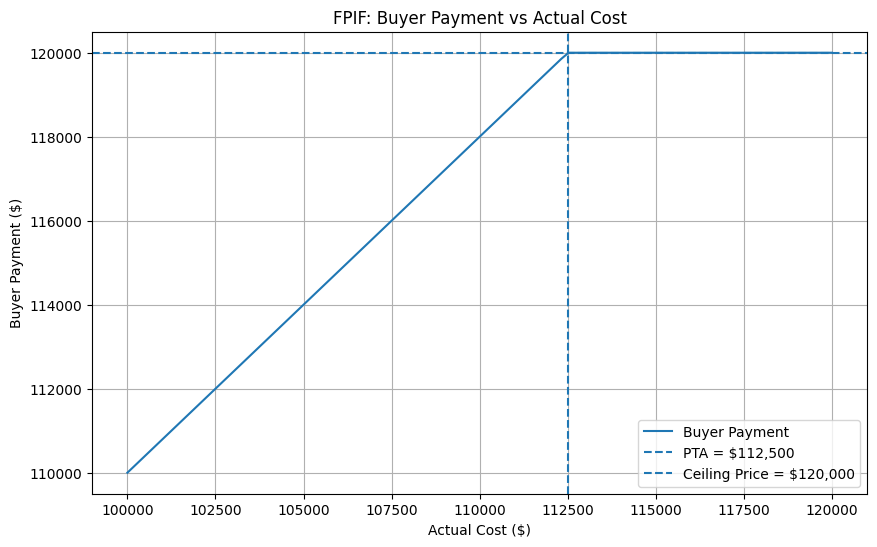

In [10]:
# FPIF: Buyer Payment vs Actual Cost

plt.figure(figsize=(10, 6))

plt.plot(
    actual_costs,
    buyer_payments,
    label="Buyer Payment"
)

plt.axvline(
    pta,
    linestyle="--",
    label=f"PTA = ${pta:,.0f}"
)

plt.axhline(
    ceiling_price,
    linestyle="--",
    label=f"Ceiling Price = ${ceiling_price:,.0f}"
)

plt.xlabel("Actual Cost ($)")
plt.ylabel("Buyer Payment ($)")
plt.title("FPIF: Buyer Payment vs Actual Cost")

plt.grid(True)
plt.legend()

plt.show()

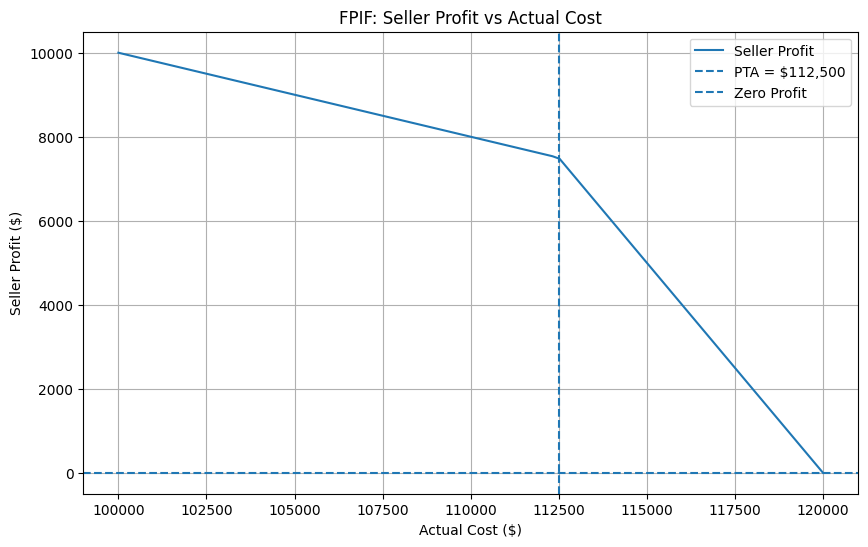

In [11]:
# FPIF: Seller Profit vs Actual Cost

plt.figure(figsize=(10, 6))

plt.plot(
    actual_costs,
    seller_profits,
    label="Seller Profit"
)

plt.axvline(
    pta,
    linestyle="--",
    label=f"PTA = ${pta:,.0f}"
)

plt.axhline(
    0,
    linestyle="--",
    label="Zero Profit"
)

plt.xlabel("Actual Cost ($)")
plt.ylabel("Seller Profit ($)")
plt.title("FPIF: Seller Profit vs Actual Cost")

plt.grid(True)
plt.legend()

plt.show()